# ĐỀ TÀI #3: RETURN REASON x SIZE x CATEGORY
## Wrong-size Heatmap and Refund Leakage

### Framework: D-Di-P-Pr (Descriptive-Diagnostic-Predictive-Prescriptive)

**Mục tiêu:**
- Đo return rate theo size và category
- Xác định lý do trả hàng chính và vùng rủi ro cao
- Dự báo xu hướng wrong_size ngắn hạn
- Đề xuất hành động giảm refund và cải thiện size guide

**Insight chính:** "Return không chỉ là vận hành, đó là vấn đề fit giữa sản phẩm và kỳ vọng khách hàng."

In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn

In [1]:
# ============================================================================
# CELL 1: CONFIG & IMPORTS
# ============================================================================
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

cwd = Path.cwd().resolve()
candidate_data_dirs = [
    cwd / 'data' / 'datathon-2026-round-1',
    cwd.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent.parent / 'data' / 'datathon-2026-round-1',
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find data/datathon-2026-round-1 from current working directory. '
        f'Current cwd: {cwd}'
    )

DATA_PATH = str(DATA_DIR) + os.sep
OUTPUT_DIR = cwd / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = str(OUTPUT_DIR) + os.sep

sns.set_theme(style='whitegrid', palette='tab20')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f'✓ Pandas: {pd.__version__}')
print(f'✓ NumPy: {np.__version__}')
print(f'✓ Seed: {SEED}')
print(f'✓ Data path: {DATA_PATH}')
print(f'✓ Output path: {OUTPUT_PATH}')

✓ Pandas: 3.0.2
✓ NumPy: 2.4.4
✓ Seed: 42
✓ Data path: D:\Datathon2026\TuNgayToiGapEm\data\datathon-2026-round-1\
✓ Output path: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_3\outputs\


## CELL 2: Load Data

In [2]:
# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
print('='*70)
print('LOADING DATA')
print('='*70)

products = pd.read_csv(f'{DATA_PATH}products.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv')
returns = pd.read_csv(f'{DATA_PATH}returns.csv')
reviews = pd.read_csv(f'{DATA_PATH}reviews.csv')

returns['return_date'] = pd.to_datetime(returns['return_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price']

print(f'\n✓ Products shape: {products.shape}')
print(f'✓ Order items shape: {order_items.shape}')
print(f'✓ Returns shape: {returns.shape}')
print(f'✓ Reviews shape: {reviews.shape}')
print(f'✓ Return reasons: {returns["return_reason"].nunique()}')

LOADING DATA

✓ Products shape: (2412, 8)
✓ Order items shape: (714669, 8)
✓ Returns shape: (39939, 7)
✓ Reviews shape: (113551, 7)
✓ Return reasons: 5


## CELL 3: Build Return Analytics Table

In [3]:
# ============================================================================
# CELL 3: BUILD FACT TABLES
# ============================================================================
item_prod = order_items.merge(products[['product_id', 'category', 'segment', 'size']], on='product_id', how='left')
ret_prod = returns.merge(products[['product_id', 'category', 'segment', 'size']], on='product_id', how='left')

ret_prod['return_quantity'] = ret_prod['return_quantity'].fillna(0)
ret_prod['refund_amount'] = ret_prod['refund_amount'].fillna(0)

size_den = item_prod.groupby('size').size().rename('order_lines')
size_num = ret_prod.groupby('size').size().rename('return_lines')
size_rate = pd.concat([size_den, size_num], axis=1).fillna(0)
size_rate['return_rate'] = size_rate['return_lines'] / size_rate['order_lines']

cat_den = item_prod.groupby('category').size().rename('order_lines')
cat_num = ret_prod.groupby('category').size().rename('return_lines')
cat_rate = pd.concat([cat_den, cat_num], axis=1).fillna(0)
cat_rate['return_rate'] = cat_rate['return_lines'] / cat_rate['order_lines']

heat_den = item_prod.groupby(['category', 'size']).size().rename('order_lines').reset_index()
heat_num = ret_prod.groupby(['category', 'size']).size().rename('return_lines').reset_index()
heat = heat_den.merge(heat_num, on=['category', 'size'], how='left').fillna({'return_lines': 0})
heat['return_rate'] = heat['return_lines'] / heat['order_lines']

wrong_size_share = (ret_prod['return_reason'] == 'wrong_size').mean() * 100

print(f'✓ Overall return lines: {len(ret_prod):,}')
print(f'✓ Overall refund amount: ${ret_prod["refund_amount"].sum():,.0f}')
print(f'✓ Wrong_size share: {wrong_size_share:.1f}%')

✓ Overall return lines: 39,939
✓ Overall refund amount: $510,598,507
✓ Wrong_size share: 35.0%


## CELL 4: Monthly Wrong-size Trend

In [4]:
# ============================================================================
# CELL 4: MONTHLY TREND
# ============================================================================
ret_prod['month'] = ret_prod['return_date'].dt.to_period('M').astype(str)
monthly = ret_prod.groupby('month').agg(
    returns=('return_id', 'count'),
    wrong_size=('return_reason', lambda x: (x == 'wrong_size').sum()),
    refund=('refund_amount', 'sum')
).reset_index()
monthly['wrong_size_rate'] = monthly['wrong_size'] / monthly['returns']

X = np.arange(len(monthly)).reshape(-1, 1)
y = monthly['wrong_size_rate'].values
lr = LinearRegression()
lr.fit(X, y)
monthly['trend'] = lr.predict(X)
next_3 = lr.predict(np.arange(len(monthly), len(monthly) + 3).reshape(-1, 1))
next_3 = np.clip(next_3, 0, 1)
forecast_wrong_size_3m = float(next_3.mean())
trend_slope = float(lr.coef_[0])

print(f'✓ Monthly periods: {len(monthly)}')
print(f'✓ Current wrong_size rate (last month): {monthly["wrong_size_rate"].iloc[-1]*100:.2f}%')
print(f'✓ Forecast wrong_size rate (next 3 months): {forecast_wrong_size_3m*100:.2f}%')
print(f'✓ Trend slope per month: {trend_slope:.6f}')

✓ Monthly periods: 126
✓ Current wrong_size rate (last month): 43.97%
✓ Forecast wrong_size rate (next 3 months): 34.68%
✓ Trend slope per month: -0.000032


---

# TẦNG 1: DESCRIPTIVE — "What happened?"

Mô tả cấu trúc return theo reason, size và category.

In [5]:
# ============================================================================
# CELL 5: DESCRIPTIVE SUMMARY
# ============================================================================
print('='*70)
print('TẦNG 1: DESCRIPTIVE — RETURN OVERVIEW')
print('='*70)

reason_dist = ret_prod['return_reason'].value_counts(normalize=True).mul(100).round(2)

print('\n📊 Return reason distribution (%):')
print(reason_dist)

print('\n📊 Return rate by size (%):')
print((size_rate['return_rate'] * 100).round(2).sort_values(ascending=False))

print('\n📊 Top 8 categories by return rate (%):')
print((cat_rate['return_rate'] * 100).round(2).sort_values(ascending=False).head(8))

TẦNG 1: DESCRIPTIVE — RETURN OVERVIEW

📊 Return reason distribution (%):
return_reason
wrong_size          34.97
defective           20.08
not_as_described    17.61
changed_mind        17.35
late_delivery        9.98
Name: proportion, dtype: float64

📊 Return rate by size (%):
size
S     5.65
L     5.62
M     5.57
XL    5.52
Name: return_rate, dtype: float64

📊 Top 8 categories by return rate (%):
category
GenZ          5.72
Outdoor       5.66
Streetwear    5.54
Casual        5.39
Name: return_rate, dtype: float64


## CELL 6: Visualization 1 - Return Reason Distribution

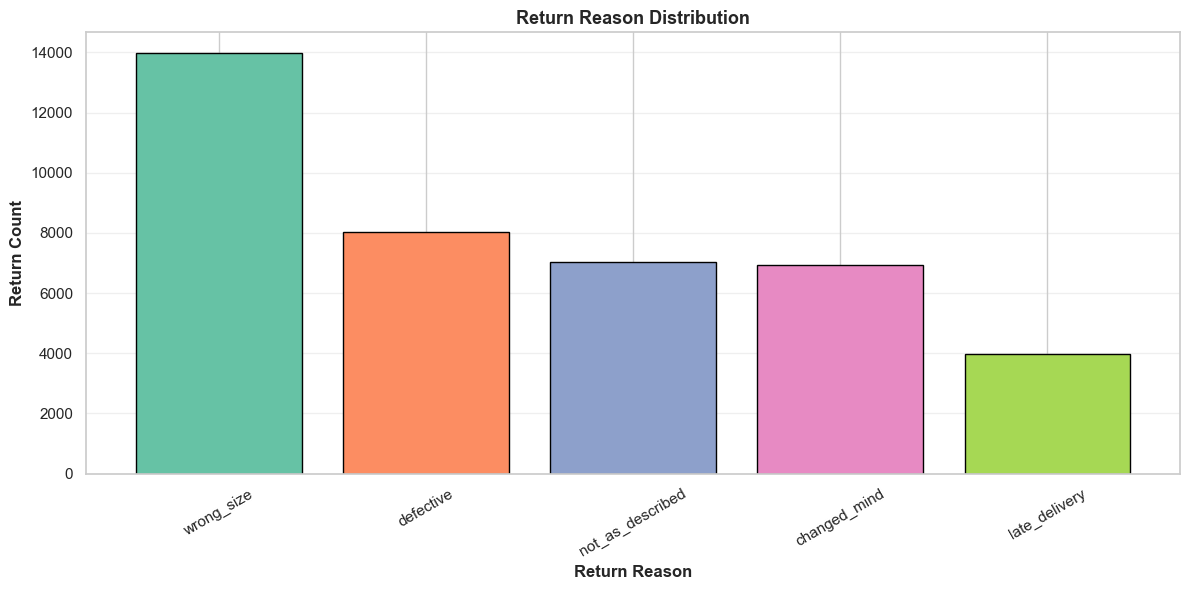

✓ Saved: 01_return_reason_distribution.png


In [6]:
# ============================================================================
# CELL 6: VISUALIZATION 1
# ============================================================================
reason_counts = ret_prod['return_reason'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(reason_counts.index, reason_counts.values, color=sns.color_palette('Set2', len(reason_counts)), edgecolor='black')
ax.set_title('Return Reason Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Return Reason', fontweight='bold')
ax.set_ylabel('Return Count', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}01_return_reason_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 01_return_reason_distribution.png')

## CELL 7: Visualization 2 - Heatmap Category x Size Return Rate

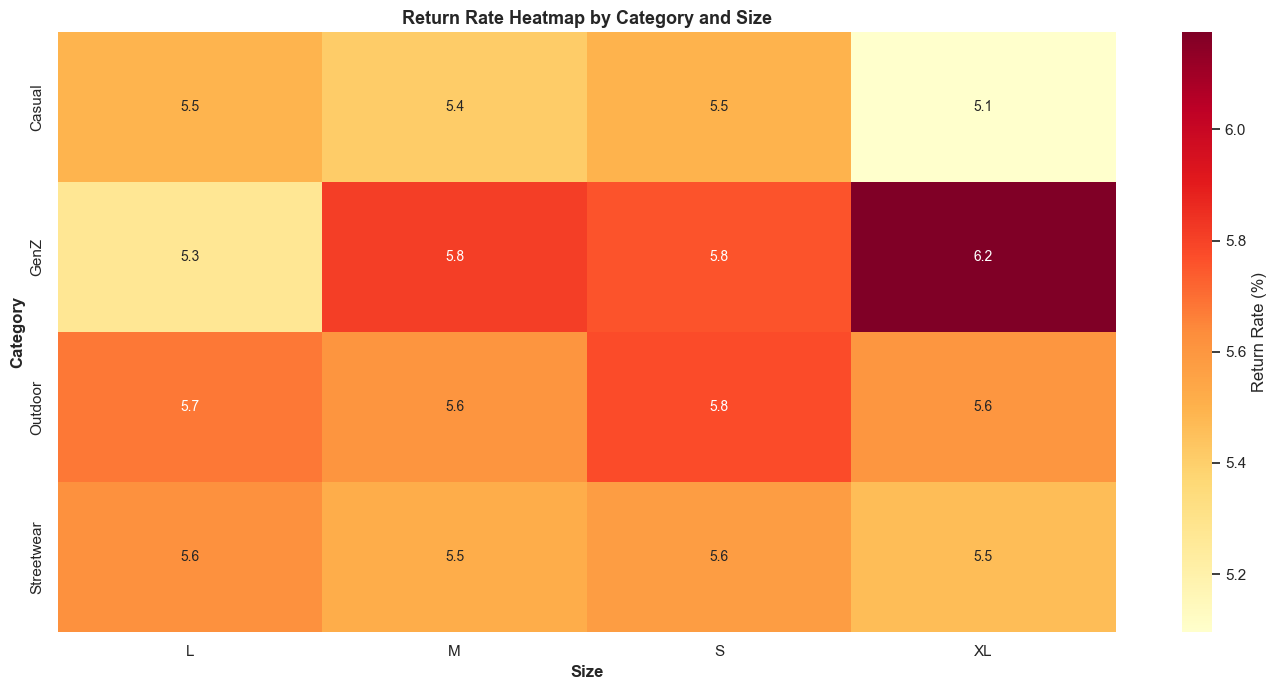

✓ Saved: 02_category_size_heatmap.png


In [7]:
# ============================================================================
# CELL 7: VISUALIZATION 2
# ============================================================================
heat_pivot = heat.pivot(index='category', columns='size', values='return_rate').fillna(0)
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heat_pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Return Rate (%)'}, ax=ax)
ax.set_title('Return Rate Heatmap by Category and Size', fontweight='bold', fontsize=13)
ax.set_xlabel('Size', fontweight='bold')
ax.set_ylabel('Category', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}02_category_size_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 02_category_size_heatmap.png')

---

# TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

Chẩn đoán leakage refund do wrong_size và dự báo xu hướng.

In [11]:
# ============================================================================
# CELL 8: DIAGNOSTIC + PREDICTIVE
# ============================================================================
print('='*70)
print('TẦNG 2-3: DIAGNOSTIC & PREDICTIVE')
print('='*70)

wrong_size_refund = ret_prod[ret_prod['return_reason'] == 'wrong_size']['refund_amount'].sum()
total_refund = ret_prod['refund_amount'].sum()
wrong_size_refund_share = (wrong_size_refund / total_refund) * 100 if total_refund > 0 else np.nan

streetwear = ret_prod[ret_prod['category'] == 'Streetwear']
street_wrong = (streetwear['return_reason'] == 'wrong_size').mean() * 100 if len(streetwear) > 0 else np.nan

top_risk_cells = heat.sort_values('return_rate', ascending=False).head(10)

print(f'\n📉 Refund leakage analysis:')
print(f'  - Total refund: ${total_refund:,.0f}')
print(f'  - Wrong-size refund: ${wrong_size_refund:,.0f} ({wrong_size_refund_share:.1f}%)')

print(f'\n📌 Streetwear wrong_size share: {street_wrong:.1f}%')

top_risk_display = top_risk_cells[['category', 'size', 'return_rate']].copy()
top_risk_display['return_rate'] = (top_risk_display['return_rate'] * 100).round(2)
print('\nTop risk category-size cells (% return rate):')
print(top_risk_display.to_string(index=False))

print(f'\n🔮 Forecast wrong_size rate (next 3 months): {forecast_wrong_size_3m*100:.2f}%')

TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

📉 Refund leakage analysis:
  - Total refund: $510,598,507
  - Wrong-size refund: $176,687,201 (34.6%)

📌 Streetwear wrong_size share: 35.0%

Top risk category-size cells (% return rate):
  category size  return_rate
      GenZ   XL         6.17
      GenZ    M         5.81
   Outdoor    S         5.78
      GenZ    S         5.76
   Outdoor    L         5.68
Streetwear    L         5.62
   Outdoor    M         5.61
   Outdoor   XL         5.60
Streetwear    S         5.58
Streetwear    M         5.52

🔮 Forecast wrong_size rate (next 3 months): 34.68%


## CELL 9: Visualization 3 - Monthly Wrong-size Trend

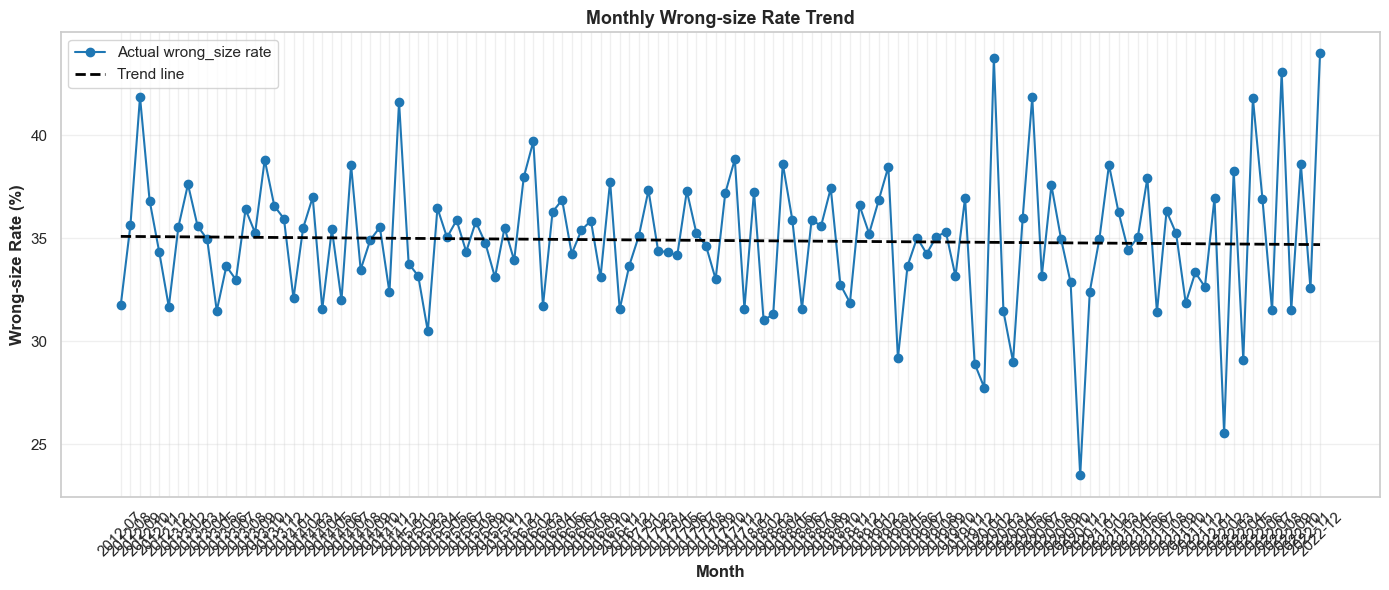

✓ Saved: 03_wrong_size_trend.png


In [9]:
# ============================================================================
# CELL 9: VISUALIZATION 3
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['month'], monthly['wrong_size_rate'] * 100, marker='o', linewidth=1.5, label='Actual wrong_size rate')
ax.plot(monthly['month'], monthly['trend'] * 100, linestyle='--', linewidth=2, color='black', label='Trend line')
ax.set_title('Monthly Wrong-size Rate Trend', fontweight='bold', fontsize=13)
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Wrong-size Rate (%)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}03_wrong_size_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 03_wrong_size_trend.png')

## CELL 10: Visualization 4 - Refund by Return Reason

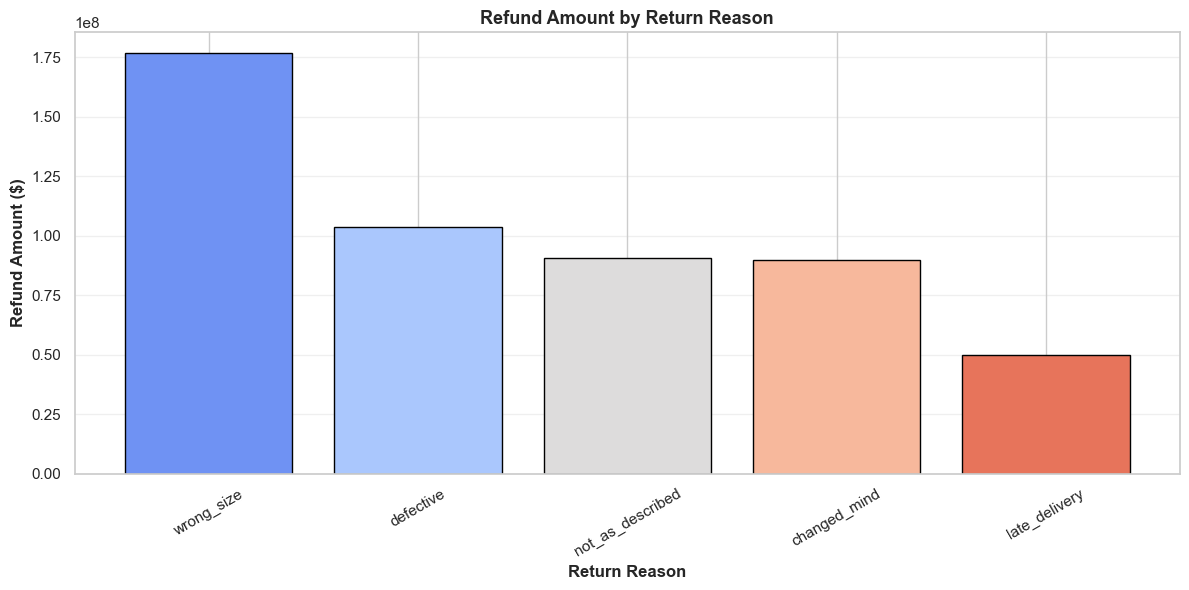

✓ Saved: 04_refund_by_reason.png


In [10]:
# ============================================================================
# CELL 10: VISUALIZATION 4
# ============================================================================
refund_reason = ret_prod.groupby('return_reason')['refund_amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(refund_reason.index, refund_reason.values, color=sns.color_palette('coolwarm', len(refund_reason)), edgecolor='black')
ax.set_title('Refund Amount by Return Reason', fontweight='bold', fontsize=13)
ax.set_xlabel('Return Reason', fontweight='bold')
ax.set_ylabel('Refund Amount ($)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}04_refund_by_reason.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 04_refund_by_reason.png')

---

# TẦNG 4: PRESCRIPTIVE — "What should we do?"

Thiết kế action plan giảm wrong_size returns và refund leakage.

In [12]:
# ============================================================================
# CELL 11: PRESCRIPTIVE RECOMMENDATIONS
# ============================================================================
print('='*70)
print('TẦNG 4: PRESCRIPTIVE — RETURN REDUCTION PLAN')
print('='*70)

target_reduction = 0.30
estimated_savings = wrong_size_refund * target_reduction

print(f'\n📊 RECOMMENDATION 1: FIX SIZE GUIDE CHO TOP RISK CELLS')
print('  - Ưu tiên top 10 category-size có return_rate cao nhất')
print(f'  - Wrong-size refund hiện tại: ${wrong_size_refund:,.0f}')
print(f'  - Nếu giảm 30% wrong_size: tiết kiệm ~${estimated_savings:,.0f}')

print(f'\n📊 RECOMMENDATION 2: SIZE ADVISOR AT PDP/CHECKOUT')
print('  - Gợi ý size theo lịch sử trả hàng theo category + size')
print('  - Cảnh báo fit risk cho SKU có return_rate bất thường')

print(f'\n📊 RECOMMENDATION 3: POST-PURCHASE FIT CONFIRMATION')
print('  - Trigger CSKH sớm cho đơn high-risk (Streetwear + extreme sizes)')
print('  - Mục tiêu giảm hoàn hàng trước khi phát sinh return')

print(f'\n📊 RECOMMENDATION 4: RETURN SCORECARD')
print('  - KPI bắt buộc: wrong_size_share, refund_leakage, top-risk-cell rate')
print(f'  - Forecast wrong_size next 3 months: {forecast_wrong_size_3m*100:.2f}%')
print('  - Review hàng tháng để điều chỉnh size chart và inventory mix')

TẦNG 4: PRESCRIPTIVE — RETURN REDUCTION PLAN

📊 RECOMMENDATION 1: FIX SIZE GUIDE CHO TOP RISK CELLS
  - Ưu tiên top 10 category-size có return_rate cao nhất
  - Wrong-size refund hiện tại: $176,687,201
  - Nếu giảm 30% wrong_size: tiết kiệm ~$53,006,160

📊 RECOMMENDATION 2: SIZE ADVISOR AT PDP/CHECKOUT
  - Gợi ý size theo lịch sử trả hàng theo category + size
  - Cảnh báo fit risk cho SKU có return_rate bất thường

📊 RECOMMENDATION 3: POST-PURCHASE FIT CONFIRMATION
  - Trigger CSKH sớm cho đơn high-risk (Streetwear + extreme sizes)
  - Mục tiêu giảm hoàn hàng trước khi phát sinh return

📊 RECOMMENDATION 4: RETURN SCORECARD
  - KPI bắt buộc: wrong_size_share, refund_leakage, top-risk-cell rate
  - Forecast wrong_size next 3 months: 34.68%
  - Review hàng tháng để điều chỉnh size chart và inventory mix


## CELL 12: Export Summary Metrics

In [13]:
# ============================================================================
# CELL 12: EXPORT SUMMARY METRICS
# ============================================================================
worst_size = (size_rate['return_rate'] * 100).idxmax()
worst_size_rate = (size_rate['return_rate'] * 100).max()
worst_cat = (cat_rate['return_rate'] * 100).idxmax()
worst_cat_rate = (cat_rate['return_rate'] * 100).max()

summary_data = {
    'Metric': [
        'Total Return Lines',
        'Total Refund Amount',
        'Wrong-size Share (%)',
        'Wrong-size Refund Share (%)',
        'Worst Size by Return Rate',
        'Worst Size Return Rate (%)',
        'Worst Category by Return Rate',
        'Worst Category Return Rate (%)',
        'Streetwear Wrong-size Share (%)',
        'Forecast Wrong-size Rate (3M, %)',
        'Trend Slope Wrong-size (per month)',
        'Est. Savings if Wrong-size -30%',
    ],
    'Value': [
        f'{len(ret_prod):,}',
        f'${ret_prod["refund_amount"].sum():,.0f}',
        f'{wrong_size_share:.1f}%',
        f'{wrong_size_refund_share:.1f}%',
        str(worst_size),
        f'{worst_size_rate:.2f}%',
        str(worst_cat),
        f'{worst_cat_rate:.2f}%',
        f'{street_wrong:.1f}%',
        f'{forecast_wrong_size_3m*100:.2f}%',
        f'{trend_slope:.6f}',
        f'${estimated_savings:,.0f}',
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f'{OUTPUT_PATH}summary_metrics.csv', index=False)

print('\n📊 SUMMARY METRICS TABLE')
print('='*70)
print(summary_df.to_string(index=False))
print(f'\n✓ Exported to: {OUTPUT_PATH}summary_metrics.csv')


📊 SUMMARY METRICS TABLE
                            Metric        Value
                Total Return Lines       39,939
               Total Refund Amount $510,598,507
              Wrong-size Share (%)        35.0%
       Wrong-size Refund Share (%)        34.6%
         Worst Size by Return Rate            S
        Worst Size Return Rate (%)        5.65%
     Worst Category by Return Rate         GenZ
    Worst Category Return Rate (%)        5.72%
   Streetwear Wrong-size Share (%)        35.0%
  Forecast Wrong-size Rate (3M, %)       34.68%
Trend Slope Wrong-size (per month)    -0.000032
   Est. Savings if Wrong-size -30%  $53,006,160

✓ Exported to: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_3\outputs\summary_metrics.csv


## CELL 13: Final Summary

In [14]:
# ============================================================================
# CELL 13: FINAL SUMMARY
# ============================================================================
print('\n' + '='*70)
print('✅ ANALYSIS COMPLETE - IDEA #3 RETURN x SIZE x CATEGORY')
print('='*70)

print(f'''\n🎯 ONE-LINER INSIGHT:
"Return không chỉ là vận hành, đó là vấn đề fit giữa sản phẩm và kỳ vọng khách hàng."

📁 OUTPUT FILES GENERATED:
  ✓ 01_return_reason_distribution.png  - Return reason distribution
  ✓ 02_category_size_heatmap.png       - Category x size return heatmap
  ✓ 03_wrong_size_trend.png            - Wrong-size monthly trend
  ✓ 04_refund_by_reason.png            - Refund leakage by reason
  ✓ summary_metrics.csv                - Key return metrics

Location: {OUTPUT_PATH}

🔑 KEY FINDINGS:
  - wrong_size là driver chính của refund leakage
  - Return risk tập trung ở một số category-size cụ thể
  - Cần size guide và scorecard theo cell-level, không chỉ overall

🚀 READY FOR:
  ✓ Part 2 EDA Diagnostic + Prescriptive
  ✓ Policy giảm return và tối ưu margin
  ✓ Input feature cho forecast/operations planning
''')


✅ ANALYSIS COMPLETE - IDEA #3 RETURN x SIZE x CATEGORY

🎯 ONE-LINER INSIGHT:
"Return không chỉ là vận hành, đó là vấn đề fit giữa sản phẩm và kỳ vọng khách hàng."

📁 OUTPUT FILES GENERATED:
  ✓ 01_return_reason_distribution.png  - Return reason distribution
  ✓ 02_category_size_heatmap.png       - Category x size return heatmap
  ✓ 03_wrong_size_trend.png            - Wrong-size monthly trend
  ✓ 04_refund_by_reason.png            - Refund leakage by reason
  ✓ summary_metrics.csv                - Key return metrics

Location: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_3\outputs\

🔑 KEY FINDINGS:
  - wrong_size là driver chính của refund leakage
  - Return risk tập trung ở một số category-size cụ thể
  - Cần size guide và scorecard theo cell-level, không chỉ overall

🚀 READY FOR:
  ✓ Part 2 EDA Diagnostic + Prescriptive
  ✓ Policy giảm return và tối ưu margin
  ✓ Input feature cho forecast/operations planning

